In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 所有库导入完成")

✓ 所有库导入完成


## 第一步：数据加载与时间戳解析

In [14]:
# 读取数据
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ 成功读取数据，形状：{df.shape}")
except Exception as e:
    raise RuntimeError(f"读取失败：{e}")

# 显示前几行
print(f"\n数据前 5 行：")
print(df.head())

# 确定列
time_col = df.columns[0]  # 第一列是时间戳
target_col = df.columns[-1]  # 最后一列是目标（CO2 容量）

print(f"\n列角色定义：")
print(f"  • 时间列：{time_col}")
print(f"  • 目标列：{target_col}")
print(f"  • 数据频率：1 分钟")
print(f"  • 总记录数：{len(df)}")

✓ 成功读取数据，形状：(10080, 59)

数据前 5 行：
                 Date      PI-2       TI-2         FI-2      PI-3       TI-3  \
0 2020-01-20 00:00:00 -0.053126  34.736652  1543.938721  0.052434  45.023132   
1 2020-01-20 00:01:00 -0.053289  34.732132  1541.767578  0.052564  45.045799   
2 2020-01-20 00:02:00 -0.053386  34.761639  1545.614746  0.052390  45.088932   
3 2020-01-20 00:03:00 -0.053370  34.731682  1544.225952  0.052236  45.071358   
4 2020-01-20 00:04:00 -0.053144  34.718353  1540.848267  0.052370  45.036755   

       O2-3      TI-32      TI-33      TI-34  ...        FI-16      TI-16  \
0  5.170577  37.777477  50.215652  61.217957  ...  9634.049805  34.619560   
1  5.139907  37.836792  50.203251  61.241829  ...  9661.376953  34.598999   
2  5.078373  37.840168  50.180534  61.217957  ...  9662.280273  34.551292   
3  4.915955  37.849812  50.215652  61.322845  ...  9656.855469  34.583843   
4  5.042109  37.914433  50.229359  61.233147  ...  9641.303711  34.584705   

         FI-151     TI

## 第二步：选择特征并时间顺序分割

In [15]:
# 选定的 10 个特征（来自相关性分析）
selected_features = ['TI-34', 'TI-33', 'TI-24', 'FI-38', 'TI-32', 'TI-242', 'TI-25', 'TI-30', 'FI-36', 'FI-30']

# 验证特征是否存在
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f"⚠ 警告：以下特征不存在：{missing_features}")
    print(f"实际列名：{list(df.columns)}")
    selected_features = [f for f in selected_features if f in df.columns]
    print(f"使用实际存在的特征：{selected_features}")

print(f"\n使用的特征（共 {len(selected_features)} 个）：")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# 提取特征和目标
X = df[selected_features].copy()
y = df[target_col].copy()

# 处理缺失值（用中位数填充）
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

print(f"\n目标变量统计：")
print(f"  • 最小值：{y.min():.6f}")
print(f"  • 最大值：{y.max():.6f}")
print(f"  • 平均值：{y.mean():.6f}")
print(f"  • 标准差：{y.std():.6f}")

# 时间顺序分割：前 80% 训练，后 20% 测试
split_idx = int(len(df) * 0.8)

X_train_raw = X.iloc[:split_idx].reset_index(drop=True)
X_test_raw = X.iloc[split_idx:].reset_index(drop=True)
y_train_raw = y.iloc[:split_idx].reset_index(drop=True)
y_test_raw = y.iloc[split_idx:].reset_index(drop=True)

print(f"\n时间顺序分割结果：")
print(f"  • 训练数据：{len(X_train_raw)} 条（前 80%）")
print(f"  • 测试数据：{len(X_test_raw)} 条（后 20%）")


使用的特征（共 10 个）：
  1. TI-34
  2. TI-33
  3. TI-24
  4. FI-38
  5. TI-32
  6. TI-242
  7. TI-25
  8. TI-30
  9. FI-36
  10. FI-30

目标变量统计：
  • 最小值：0.416014
  • 最大值：1.000707
  • 平均值：0.874542
  • 标准差：0.062135

时间顺序分割结果：
  • 训练数据：8064 条（前 80%）
  • 测试数据：2016 条（后 20%）


## 第三步：特征标准化（用训练集统计量）

In [16]:
# 在训练集上计算均值和标准差
scaler = StandardScaler()
scaler.fit(X_train_raw)  # 只在训练集上 fit

# 用训练集的统计量标准化训练集和测试集
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 转换为 DataFrame 保留列名
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

print("✓ 特征标准化完成")
print(f"\n训练集特征统计（标准化后）：")
print(f"  • 均值：{X_train_scaled.mean().values}")
print(f"  • 方差：{X_train_scaled.var().values}")
print(f"\n测试集中某些样本可能超出 [-1, 1] 范围，这是正常的")

✓ 特征标准化完成

训练集特征统计（标准化后）：
  • 均值：[-9.40770830e-16  9.32345030e-16  1.82553487e-15 -4.63763177e-17
  1.29966584e-16 -8.63231444e-17  1.97565729e-15 -2.77748503e-16
  8.57418055e-16  1.02575421e-15]
  • 方差：[1.00012402 1.00012402 1.00012402 1.00012402 1.00012402 1.00012402
 1.00012402 1.00012402 1.00012402 1.00012402]

测试集中某些样本可能超出 [-1, 1] 范围，这是正常的


## 第四步：构造滑动窗口数据

**规则：** 用前 10 个时间步（10 分钟）的特征值作为输入，预测下一个时间步（第 11 分钟）的目标值。

In [17]:
def create_sliding_windows(X, y, window_size=10):
    """
    创建滑动窗口数据
    
    参数：
      X: 特征数据 (n_samples, n_features)
      y: 目标数据 (n_samples,)
      window_size: 窗口大小（默认 10）
    
    返回：
      X_windows: 窗口化特征 (n_windows, window_size * n_features)
      y_windows: 窗口化目标 (n_windows,)
    """
    X_windows = []
    y_windows = []
    
    for i in range(len(X) - window_size):
        # 取第 i 到 i+window_size-1 的特征，展平为一行
        window = X.iloc[i:i+window_size].values.flatten()
        X_windows.append(window)
        
        # 目标是第 i+window_size 时刻的值
        y_windows.append(y.iloc[i+window_size])
    
    return np.array(X_windows), np.array(y_windows)

# 构造训练窗口
X_train_windows, y_train_windows = create_sliding_windows(X_train_scaled, y_train_raw, window_size=10)

# 构造测试窗口
X_test_windows, y_test_windows = create_sliding_windows(X_test_scaled, y_test_raw, window_size=10)

print(f"✓ 滑动窗口构造完成")
print(f"\n训练数据：")
print(f"  • 样本数：{X_train_windows.shape[0]}")
print(f"  • 特征维度：{X_train_windows.shape[1]}（10 分钟 × {len(selected_features)} 特征）")
print(f"\n测试数据：")
print(f"  • 样本数：{X_test_windows.shape[0]}")
print(f"  • 特征维度：{X_test_windows.shape[1]}")

print(f"\n样本示例（训练集第 1 个样本）：")
print(f"  输入形状：{X_train_windows[0].shape}")
print(f"  输入（前 20 个值）：{X_train_windows[0][:20]}")
print(f"  目标值：{y_train_windows[0]}")

✓ 滑动窗口构造完成

训练数据：
  • 样本数：8054
  • 特征维度：100（10 分钟 × 10 特征）

测试数据：
  • 样本数：2006
  • 特征维度：100

样本示例（训练集第 1 个样本）：
  输入形状：(100,)
  输入（前 20 个值）：[-0.79322447 -0.75028492 -1.03949041 -0.18949661 -1.1018004  -1.07026694
 -1.10726384 -0.64476352 -0.11797555 -0.022661   -0.78339202 -0.75552061
 -1.03078248 -0.12866631 -1.06890032 -1.08552628 -1.05173519 -0.61728164
 -0.21489631 -0.20098893]
  目标值：0.8461687235367473


## 第五步：随机森林模型训练

In [18]:
# 训练随机森林（使用默认超参数）
print("正在训练随机森林...")
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_model.fit(X_train_windows, y_train_windows)

print(f"✓ 模型训练完成")
print(f"\n模型配置：")
print(f"  • 模型类型：RandomForestRegressor")
print(f"  • 树的个数：{rf_model.n_estimators}")
print(f"  • 最大深度：{rf_model.max_depth}")
print(f"  • 最小样本分割：{rf_model.min_samples_split}")
print(f"  • 最小样本叶子：{rf_model.min_samples_leaf}")

# 在训练集上的性能
y_train_pred = rf_model.predict(X_train_windows)
train_r2 = r2_score(y_train_windows, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_windows, y_train_pred))
train_mae = mean_absolute_error(y_train_windows, y_train_pred)

print(f"\n训练集性能：")
print(f"  • R²：{train_r2:.4f}")
print(f"  • RMSE：{train_rmse:.6f}")
print(f"  • MAE：{train_mae:.6f}")

正在训练随机森林...
✓ 模型训练完成

模型配置：
  • 模型类型：RandomForestRegressor
  • 树的个数：100
  • 最大深度：None
  • 最小样本分割：2
  • 最小样本叶子：1

训练集性能：
  • R²：0.9980
  • RMSE：0.002103
  • MAE：0.001212
✓ 模型训练完成

模型配置：
  • 模型类型：RandomForestRegressor
  • 树的个数：100
  • 最大深度：None
  • 最小样本分割：2
  • 最小样本叶子：1

训练集性能：
  • R²：0.9980
  • RMSE：0.002103
  • MAE：0.001212


## 第六步：模型性能评估（测试集）

In [19]:
# 在测试集上预测
y_test_pred = rf_model.predict(X_test_windows)

# 计算性能指标
test_r2 = r2_score(y_test_windows, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_windows, y_test_pred))
test_mae = mean_absolute_error(y_test_windows, y_test_pred)

# 计算残差
residuals = y_test_windows - y_test_pred
residuals_std = np.std(residuals)
residuals_mean = np.mean(residuals)

print("="*80)
print("测试集性能评估结果")
print("="*80)

print(f"\n【预测精度指标】")
print(f"  • R² 分数：{test_r2:.4f}")
print(f"    └─ 说明：模型解释了 {test_r2*100:.2f}% 的目标变量方差")
print(f"  • RMSE（均方根误差）：{test_rmse:.6f}")
print(f"    └─ 说明：平均预测偏差")
print(f"  • MAE（平均绝对误差）：{test_mae:.6f}")
print(f"    └─ 说明：平均绝对偏差")

print(f"\n【预测值与实际值统计】")
print(f"  实际值：")
print(f"    • 最小：{y_test_windows.min():.6f}，最大：{y_test_windows.max():.6f}")
print(f"    • 均值：{y_test_windows.mean():.6f}，标准差：{y_test_windows.std():.6f}")
print(f"  预测值：")
print(f"    • 最小：{y_test_pred.min():.6f}，最大：{y_test_pred.max():.6f}")
print(f"    • 均值：{y_test_pred.mean():.6f}，标准差：{y_test_pred.std():.6f}")

print(f"\n【残差分析】")
print(f"  • 残差均值：{residuals_mean:.6f}（接近 0 为好）")
print(f"  • 残差标准差：{residuals_std:.6f}")
print(f"  • 残差最小值：{residuals.min():.6f}")
print(f"  • 残差最大值：{residuals.max():.6f}")

测试集性能评估结果

【预测精度指标】
  • R² 分数：-0.3465
    └─ 说明：模型解释了 -34.65% 的目标变量方差
  • RMSE（均方根误差）：0.107674
    └─ 说明：平均预测偏差
  • MAE（平均绝对误差）：0.094789
    └─ 说明：平均绝对偏差

【预测值与实际值统计】
  实际值：
    • 最小：0.416014，最大：1.000707
    • 均值：0.912037，标准差：0.092792
  预测值：
    • 最小：0.593819，最大：0.944914
    • 均值：0.841798，标准差：0.095788

【残差分析】
  • 残差均值：0.070239（接近 0 为好）
  • 残差标准差：0.081610
  • 残差最小值：-0.376559
  • 残差最大值：0.396871


## 第七步：结果可视化

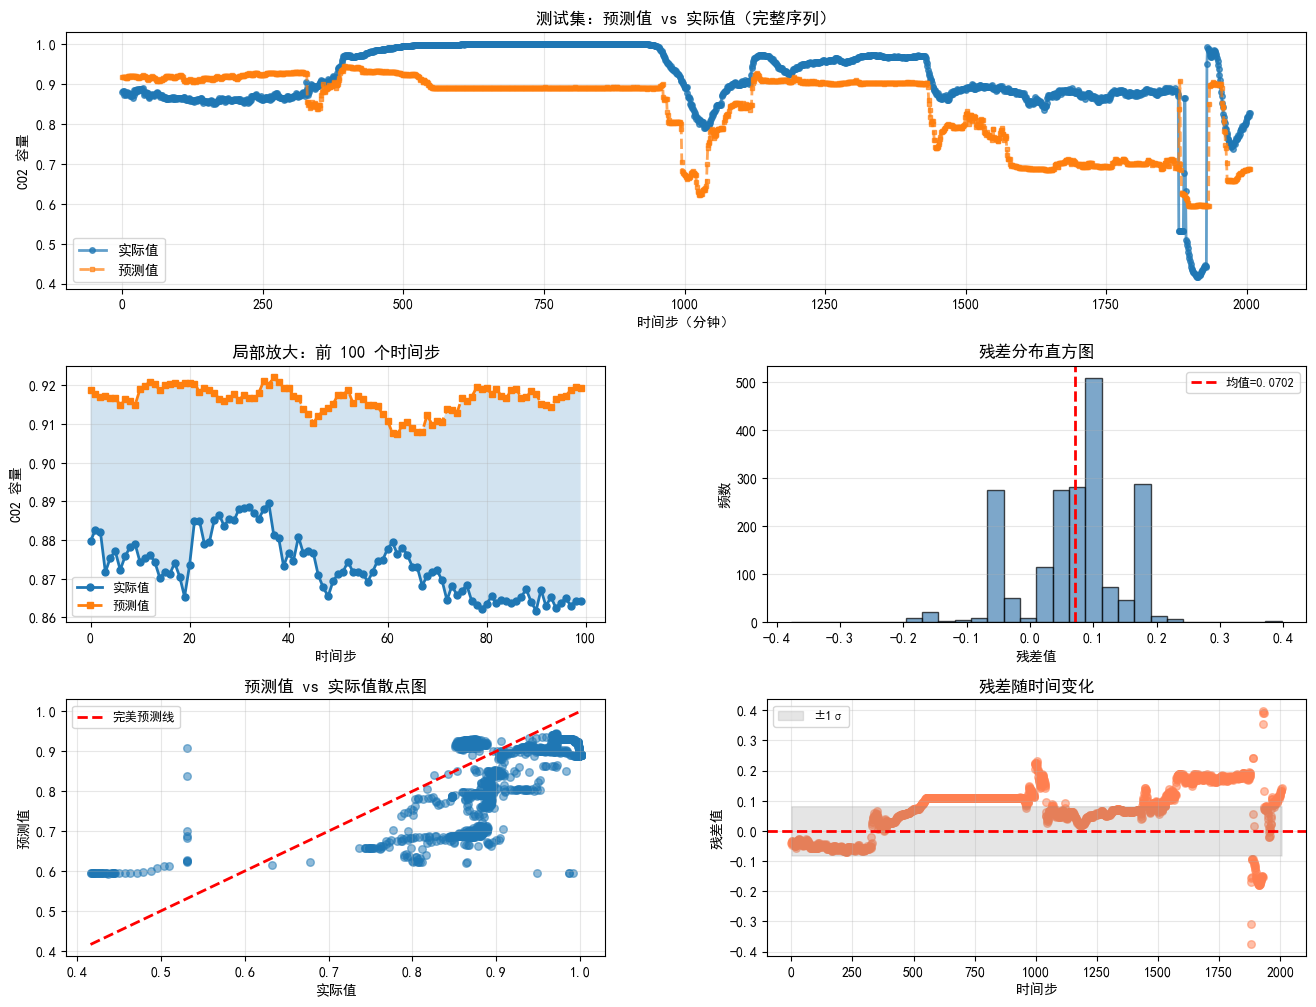

✓ 可视化图表已保存为 'time_series_prediction_results.png'


In [20]:
# 创建大图表
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 图 1：时序预测对比（全体）
ax1 = fig.add_subplot(gs[0, :])
time_steps = np.arange(len(y_test_windows))
ax1.plot(time_steps, y_test_windows, 'o-', label='实际值', linewidth=2, markersize=4, alpha=0.7)
ax1.plot(time_steps, y_test_pred, 's--', label='预测值', linewidth=2, markersize=3, alpha=0.7)
ax1.set_xlabel('时间步（分钟）', fontweight='bold')
ax1.set_ylabel('CO2 容量', fontweight='bold')
ax1.set_title('测试集：预测值 vs 实际值（完整序列）', fontweight='bold', fontsize=12)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# 图 2：时序预测对比（局部放大）
ax2 = fig.add_subplot(gs[1, 0])
plot_range = slice(0, min(100, len(y_test_windows)))  # 显示前 100 个
ax2.plot(time_steps[plot_range], y_test_windows[plot_range], 'o-', label='实际值', linewidth=2, markersize=5)
ax2.plot(time_steps[plot_range], y_test_pred[plot_range], 's--', label='预测值', linewidth=2, markersize=4)
ax2.fill_between(time_steps[plot_range], y_test_windows[plot_range], y_test_pred[plot_range], alpha=0.2)
ax2.set_xlabel('时间步', fontweight='bold')
ax2.set_ylabel('CO2 容量', fontweight='bold')
ax2.set_title('局部放大：前 100 个时间步', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 图 3：残差分布
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axvline(residuals_mean, color='red', linestyle='--', linewidth=2, label=f'均值={residuals_mean:.4f}')
ax3.set_xlabel('残差值', fontweight='bold')
ax3.set_ylabel('频数', fontweight='bold')
ax3.set_title('残差分布直方图', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# 图 4：实际值 vs 预测值散点图
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(y_test_windows, y_test_pred, alpha=0.5, s=30)
# 添加 45 度参考线
min_val = min(y_test_windows.min(), y_test_pred.min())
max_val = max(y_test_windows.max(), y_test_pred.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='完美预测线')
ax4.set_xlabel('实际值', fontweight='bold')
ax4.set_ylabel('预测值', fontweight='bold')
ax4.set_title('预测值 vs 实际值散点图', fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 图 5：残差随时间变化
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(time_steps, residuals, alpha=0.5, s=30, color='coral')
ax5.axhline(0, color='red', linestyle='--', linewidth=2)
ax5.fill_between(time_steps, -residuals_std, residuals_std, alpha=0.2, color='gray', label='±1σ')
ax5.set_xlabel('时间步', fontweight='bold')
ax5.set_ylabel('残差值', fontweight='bold')
ax5.set_title('残差随时间变化', fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

plt.savefig('time_series_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 可视化图表已保存为 'time_series_prediction_results.png'")

## 第八步：特征重要性分析


【特征重要性分析】
    特征     总重要性    平均重要性
 TI-34 0.750321 0.075032
 TI-30 0.159815 0.015981
 TI-32 0.028195 0.002819
 TI-33 0.026843 0.002684
 FI-30 0.009751 0.000975
TI-242 0.007827 0.000783
 TI-24 0.007293 0.000729
 TI-25 0.004098 0.000410
 FI-36 0.002959 0.000296
 FI-38 0.002899 0.000290


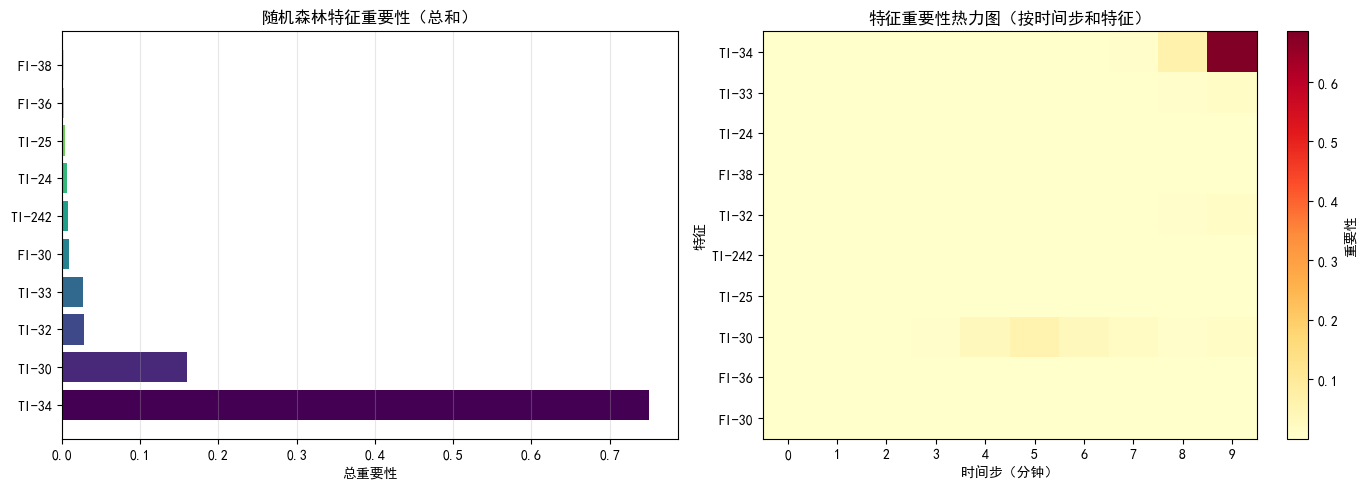


✓ 特征重要性图表已保存为 'feature_importance_analysis.png'


In [21]:
# 获取特征重要性
feature_importance = rf_model.feature_importances_

# 由于输入是展平的窗口，需要重新组织
# 形状：(10 分钟 × 10 特征) = 100 维
n_features_per_window = len(selected_features)  # 10
window_size = 10

# 按时间步和特征分组重要性
importance_matrix = feature_importance.reshape(window_size, n_features_per_window)

# 计算各特征在所有时间步的总重要性
feature_total_importance = importance_matrix.sum(axis=0)
feature_importance_df = pd.DataFrame({
    '特征': selected_features,
    '总重要性': feature_total_importance,
    '平均重要性': feature_total_importance / window_size
}).sort_values('总重要性', ascending=False)

print("\n【特征重要性分析】")
print(feature_importance_df.to_string(index=False))

# 可视化特征重要性
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图 1：特征总重要性条形图
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))
bars = ax1.barh(range(len(feature_importance_df)), feature_importance_df['总重要性'], color=colors)
ax1.set_yticks(range(len(feature_importance_df)))
ax1.set_yticklabels(feature_importance_df['特征'])
ax1.set_xlabel('总重要性', fontweight='bold')
ax1.set_title('随机森林特征重要性（总和）', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 图 2：特征重要性随时间步变化的热力图
ax2 = axes[1]
im = ax2.imshow(importance_matrix.T, aspect='auto', cmap='YlOrRd')
ax2.set_xlabel('时间步（分钟）', fontweight='bold')
ax2.set_ylabel('特征', fontweight='bold')
ax2.set_xticks(range(window_size))
ax2.set_yticks(range(len(selected_features)))
ax2.set_yticklabels(selected_features)
ax2.set_title('特征重要性热力图（按时间步和特征）', fontweight='bold')
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('重要性', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ 特征重要性图表已保存为 'feature_importance_analysis.png'")

## 第九步：结果汇总与保存

In [ ]:
# 创建汇总报告
summary_report = f"""
{'='*80}
时序预测模型性能总结报告
{'='*80}

【数据配置】
  • 原始数据点数：{len(df)}
  • 采样频率：1 分钟/条
  • 时间跨度：约 {len(df)} 分钟
  • 选定特征数：{len(selected_features)}

【数据分割】
  • 训练集：{len(X_train_raw)} 条（前 80%）
  • 测试集：{len(X_test_raw)} 条（后 20%）
  • 训练窗口数：{len(X_train_windows)}（每个窗口 10 分钟）
  • 测试窗口数：{len(X_test_windows)}（每个窗口 10 分钟）

【模型配置】
  • 模型类型：随机森林回归器
  • 树的数量：{rf_model.n_estimators}
  • 输入特征维度：{X_train_windows.shape[1]}（10 分钟 × {len(selected_features)} 特征）
  • 预测任务：前 10 分钟 → 下 1 分钟

【性能指标】

  训练集：
    • R²：{train_r2:.4f}
    • RMSE：{train_rmse:.6f}
    • MAE：{train_mae:.6f}

  测试集：
    • R²：{test_r2:.4f}
    • RMSE：{test_rmse:.6f}
    • MAE：{test_mae:.6f}

【预测精度解释】
  • R² = {test_r2:.4f}：模型解释了测试集 {test_r2*100:.2f}% 的目标变量方差
  • RMSE = {test_rmse:.6f}：平均预测误差（在原始数据尺度上）
  • MAE = {test_mae:.6f}：平均绝对偏差

【残差分析】
  • 残差均值：{residuals_mean:.6f}（接近 0 表示预测无偏）
  • 残差标准差：{residuals_std:.6f}
  • 残差范围：[{residuals.min():.6f}, {residuals.max():.6f}]

【Top 5 重要特征】
  • {feature_importance_df.iloc[0]['特征']}：{feature_importance_df.iloc[0]['总重要性']:.4f}
  • {feature_importance_df.iloc[1]['特征']}：{feature_importance_df.iloc[1]['总重要性']:.4f}
  • {feature_importance_df.iloc[2]['特征']}：{feature_importance_df.iloc[2]['总重要性']:.4f}
  • {feature_importance_df.iloc[3]['特征']}：{feature_importance_df.iloc[3]['总重要性']:.4f}
  • {feature_importance_df.iloc[4]['特征']}：{feature_importance_df.iloc[4]['总重要性']:.4f}

{'='*80}
"""

print(summary_report)

# 保存报告
with open('time_series_prediction_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)
print("✓ 报告已保存为 'time_series_prediction_report.txt'")


时序预测模型性能总结报告

【数据配置】
  • 原始数据点数：10080
  • 采样频率：1 分钟/条
  • 时间跨度：约 10080 分钟
  • 选定特征数：10

【数据分割】
  • 训练集：8064 条（前 80%）
  • 测试集：2016 条（后 20%）
  • 训练窗口数：8054（每个窗口 10 分钟）
  • 测试窗口数：2006（每个窗口 10 分钟）

【模型配置】
  • 模型类型：随机森林回归器
  • 树的数量：100
  • 输入特征维度：100（10 分钟 × 10 特征）
  • 预测任务：前 10 分钟 → 下 1 分钟

【性能指标】

  训练集：
    • R²：0.9980
    • RMSE：0.002103
    • MAE：0.001212

  测试集：
    • R²：-0.3465
    • RMSE：0.107674
    • MAE：0.094789

【预测精度解释】
  • R² = -0.3465：模型解释了测试集 -34.65% 的目标变量方差
  • RMSE = 0.107674：平均预测误差（在原始数据尺度上）
  • MAE = 0.094789：平均绝对偏差

【残差分析】
  • 残差均值：0.070239（接近 0 表示预测无偏）
  • 残差标准差：0.081610
  • 残差范围：[-0.376559, 0.396871]

【Top 5 重要特征】
  • TI-34：0.7503
  • TI-30：0.1598
  • TI-32：0.0282
  • TI-33：0.0268
  • FI-30：0.0098


✓ 报告已保存为 'time_series_prediction_report.txt'


In [ ]:
# 保存预测结果为 CSV
results_df = pd.DataFrame({
    '时间步': np.arange(len(y_test_windows)),
    '实际值': y_test_windows,
    '预测值': y_test_pred,
    '残差': residuals,
    '绝对误差': np.abs(residuals),
    '相对误差(%)': np.abs(residuals) / np.abs(y_test_windows) * 100
})

results_df.to_csv('time_series_predictions.csv', index=False, encoding='utf-8-sig')
print("✓ 预测结果已保存为 'time_series_predictions.csv'")

# 保存性能指标汇总
metrics_summary = pd.DataFrame({
    '指标': ['R²', 'RMSE', 'MAE', '残差均值', '残差标准差'],
    '训练集': [train_r2, train_rmse, train_mae, np.nan, np.nan],
    '测试集': [test_r2, test_rmse, test_mae, residuals_mean, residuals_std]
})

metrics_summary.to_csv('performance_metrics.csv', index=False, encoding='utf-8-sig')
print("✓ 性能指标已保存为 'performance_metrics.csv'")

print("\n" + "="*80)
print("✅ 所有文件生成完成！")
print("="*80)
print("\n生成的文件：")
print("  1. time_series_prediction_results.png - 预测结果可视化（5 个子图）")
print("  2. feature_importance_analysis.png - 特征重要性分析")
print("  3. time_series_prediction_report.txt - 性能汇总报告")
print("  4. time_series_predictions.csv - 详细预测结果")
print("  5. performance_metrics.csv - 性能指标汇总")

✓ 预测结果已保存为 'time_series_predictions.csv'
✓ 性能指标已保存为 'performance_metrics.csv'

✅ 所有文件生成完成！

生成的文件：
  1. time_series_prediction_results.png - 预测结果可视化（5 个子图）
  2. feature_importance_analysis.png - 特征重要性分析
  3. time_series_prediction_report.txt - 性能汇总报告
  4. time_series_predictions.csv - 详细预测结果
  5. performance_metrics.csv - 性能指标汇总
